In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/philippe/MolGenDocking


In [2]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from tqdm import tqdm

warnings.filterwarnings("ignore")

from notebooks.utils import *

## Loading

In [3]:
MOLSTRAL_PATH = Path("MolGenOutput/test_ood")
FIG_PATH = "MolGenDocking-latex/Figures/Results/MolGen"
os.makedirs(FIG_PATH, exist_ok=True)

files = [f for d in MOLSTRAL_PATH.iterdir() for f in d.iterdir() if "" in str(f) and str(f).endswith("_scored.jsonl")]
# files = [Path("MolGenOutput/test_ood/RL-Mistral-24B-100/RL-Mistral-24B-100_0_scored.jsonl")]
files = sorted(files)[::-1]

print("Total files:", len(files))
save_df_path = Path("MolGenOutput/test_ood.csv")
if save_df_path.exists():
    df = pd.read_csv(save_df_path)
else:
    df = load_molgen_results(files[:])
    df.to_csv(save_df_path, index=False)

df.Model = df.Model.apply(lambda x: x.replace("Mistral-Small", "Mistral-Small-4"))

Total files: 118


In [4]:
df.groupby("Model").prompt_id.count()

Model
ChemDFM-R          128000
ChemDFM-v2.0       128000
Llama-3.3          128000
MiniMax-M2         128000
Mistral-Small-4    128000
Qwen3              128000
Qwen3-Next         128000
R1-Llama           128000
R1-Qwen            128000
RL-Mistral         128000
RL-Molstral          6272
ether0             128000
gemma-3            128000
gemma-4            128000
gpt-oss            128000
Name: prompt_id, dtype: int64

In [5]:
sub_sample_prompts = df[df.Model == "gemma-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "RL-Molstral"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "Mistral-Small-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]


In [6]:
df.groupby(["Model", "prompt_id"]).valid.count().reset_index().groupby("Model").valid.sum()

Model
ChemDFM-R          6272
ChemDFM-v2.0       6272
Llama-3.3          6272
MiniMax-M2         6272
Mistral-Small-4    6272
Qwen3              6272
Qwen3-Next         6272
R1-Llama           6272
R1-Qwen            6272
RL-Mistral         6272
RL-Molstral        6272
ether0             6272
gemma-3            6272
gemma-4            6272
gpt-oss            6272
Name: valid, dtype: int64

In [7]:
min_vals = df.groupby(["Model", "prompt_id"]).reward.count().reset_index().groupby("Model").reward.min().min()

df = df.groupby(["Model", "prompt_id"]).sample(min_vals, random_state=42).reset_index()
df

,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
0,1700663,104510,0.06125,ChemDFM-R-14B,1,sample_74052_model_0,minimize,Cc1ccc(C(=O)Nc2ccc(CN3CC[C@H](O)C3)cc2)cc1C#Cc...,1,valid,ChemDFM-R
1,1700648,104510,0.52950,ChemDFM-R-14B,1,sample_74052_model_0,minimize,CC(C)OC(=O)N1CCN(Cc2cccnc2)CC1,1,valid,ChemDFM-R
2,1700627,104510,0.49750,ChemDFM-R-14B,1,sample_74052_model_0,minimize,O=C(c1cccc2c1OCCO2)N1CCN(CCCOc2ccc(F)cc2)CC1,1,valid,ChemDFM-R
3,1700639,104510,0.68150,ChemDFM-R-14B,1,sample_74052_model_0,minimize,CC(C)CC1NC(=O)c2nc(Cc3ccccc3)sc2-c2ccccc21,1,valid,ChemDFM-R
4,1700706,104510,0.80225,ChemDFM-R-14B,1,sample_74052_model_0,minimize,Cc1nc(NCc2c(C)cc(C)[nH]c2=O)c2c3c(sc2n1)CN(C)CC3,1,valid,ChemDFM-R
...,...,...,...,...,...,...,...,...,...,...,...
90400,26704,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,no valid SMILES,gpt-oss
90401,26706,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,no valid SMILES,gpt-oss
90402,26738,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,multiple SMILES,gpt-oss
90403,26705,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,multiple SMILES,gpt-oss


# Validity Plot

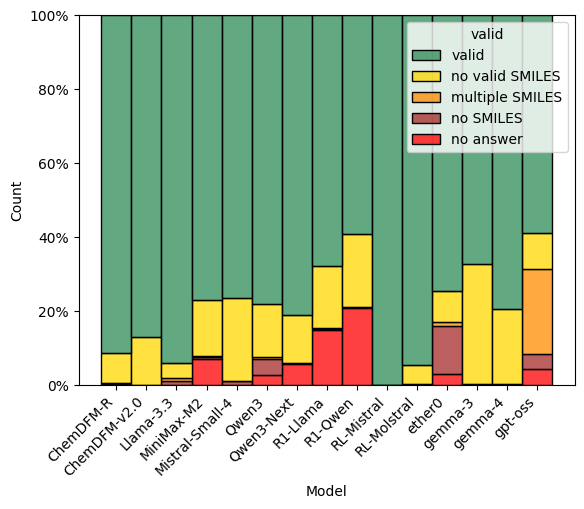

In [8]:
cmap = {
    "valid": "seagreen",
    "no valid SMILES": "gold",
    "multiple SMILES": "darkorange",
    "no SMILES": "brown",
    "no answer": "red"
}

ax = sns.histplot(data=df, x="Model", hue="valid", multiple="stack", stat="count", palette= cmap, hue_order=list(cmap.keys()))
# rotate x labels
max_count = min_vals * df.prompt_id.nunique()
ax.set_ylim(0, max_count)

yticks = np.linspace(0, max_count, 6)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y / max_count * 100)}%" for y in yticks])
_ = plt.xticks(rotation=45, ha='right')
# Replace y_ticks with percentages from 0 to 100

plt.savefig(f"{FIG_PATH}/validity.pdf", bbox_inches='tight')

# Uniqueness and Diversity Metrics

In [9]:
df

,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
0,1700663,104510,0.06125,ChemDFM-R-14B,1,sample_74052_model_0,minimize,Cc1ccc(C(=O)Nc2ccc(CN3CC[C@H](O)C3)cc2)cc1C#Cc...,1,valid,ChemDFM-R
1,1700648,104510,0.52950,ChemDFM-R-14B,1,sample_74052_model_0,minimize,CC(C)OC(=O)N1CCN(Cc2cccnc2)CC1,1,valid,ChemDFM-R
2,1700627,104510,0.49750,ChemDFM-R-14B,1,sample_74052_model_0,minimize,O=C(c1cccc2c1OCCO2)N1CCN(CCCOc2ccc(F)cc2)CC1,1,valid,ChemDFM-R
3,1700639,104510,0.68150,ChemDFM-R-14B,1,sample_74052_model_0,minimize,CC(C)CC1NC(=O)c2nc(Cc3ccccc3)sc2-c2ccccc21,1,valid,ChemDFM-R
4,1700706,104510,0.80225,ChemDFM-R-14B,1,sample_74052_model_0,minimize,Cc1nc(NCc2c(C)cc(C)[nH]c2=O)c2c3c(sc2n1)CN(C)CC3,1,valid,ChemDFM-R
...,...,...,...,...,...,...,...,...,...,...,...
90400,26704,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,no valid SMILES,gpt-oss
90401,26706,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,no valid SMILES,gpt-oss
90402,26738,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,multiple SMILES,gpt-oss
90403,26705,65010,0.00000,gpt-oss-120b,1,sample_621651_model_0,minimize,NaN,0,multiple SMILES,gpt-oss


In [10]:
import re


valid_smiles_pattern = re.compile(r"^[A-Za-z0-9=#:\+\-\[\]\(\)/\\@.%]+$")
mkd_pattern = re.compile(r"^(\*\*|[-*'])(.+)\1$")

def get_mol(smi):
    if not isinstance(smi, str):
        return None
    smi = smi.strip()
    m = mkd_pattern.match(smi)
    x = m.group(2) if m else smi
    return Chem.MolFromSmiles(x)



df["Mol"] = df["smiles"].progress_apply(get_mol)
df["CanSMI"] = df["Mol"].progress_apply(lambda x: None if x is None else Chem.MolToSmiles(x))


100%|██████████| 90405/90405 [00:03<00:00, 24382.28it/s]


## Computations

Compute the uniqueness of the generated smiles in each prompt

In [11]:
uniq_df = df[df.validity == 1].groupby(["Model", "prompt_id"]).agg(
    **{f"{k}":pd.NamedAgg(column="CanSMI", aggfunc=aggregate_molgen_fn("uniqueness", k)) for k in list(range(1,100,10))}
).reset_index()
uniq_df = uniq_df.melt(id_vars=["Model"], value_vars=[str(k) for k in list(range(1,100,10))], var_name="n_rollout")
uniq_df["n_rollout"] = uniq_df["n_rollout"].apply(int)

Diversity in each prompt (ecfp4)

In [12]:
fp_fn = fp_name_to_fn("ecfp4-2048")

sub_df = df[df.Mol.apply(lambda x: x is not None)].drop_duplicates(subset=["prompt_id", "CanSMI"])
sub_df["fps"] = sub_df["Mol"].progress_apply(fp_fn)

sim_df = sub_df.groupby(["Model", "prompt_id"]).agg(
    **{
        f"{k}":pd.NamedAgg(
            column="fps",
            aggfunc=aggregate_molgen_fn("diversity",k, is_fp=True))
        for k in [50]
    }
).reset_index()
sim_df = sim_df.melt(id_vars=["Model"], value_vars=[str(k) for k in [50]], var_name="n_rollout")
sim_df["n_rollout"] = sim_df["n_rollout"].apply(int)

100%|██████████| 52142/52142 [00:01<00:00, 28330.92it/s]


## Plots

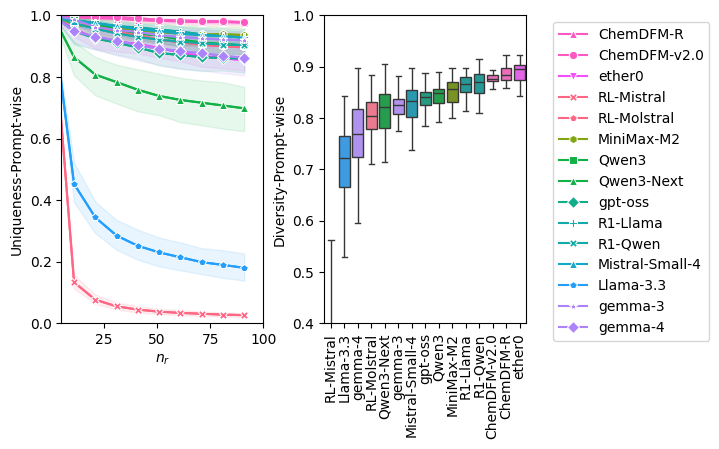

In [13]:
from notebooks.utils import CMAP_MODELS, MARKER_MODELS

fig, axes = plt.subplots(1, 2, figsize=(6,4), sharey=False, gridspec_kw={"wspace":0.3})

ax = axes[0]
sns.lineplot(uniq_df, x="n_rollout", y="value", hue="Model", ax=ax, legend=False, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), err_kws={"alpha":0.1})
sns.lineplot(uniq_df[uniq_df.n_rollout % 10 == 1], x="n_rollout", y="value", hue="Model", ax=ax, legend=True, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), errorbar=None, style="Model", dashes=False, markers = MARKER_MODELS)

ax.set_ylabel("Uniqueness-Prompt-wise")
ax.set_xlabel("$n_r$")
ax.set_ylim(0,1)
ax.set_xlim(5,100)
# Move legend below plot
ax.legend(bbox_to_anchor=(2.4, 1.0), loc='upper left', ncols=1)

ax = axes[1]
x_order = sim_df.groupby("Model")["value"].median().sort_values().index.tolist()
sns.boxplot(sim_df, x="Model", y="value", hue="Model", ax=ax, legend = False, order=x_order, palette=CMAP_MODELS,fliersize=0)
ax.set_ylabel("Diversity-Prompt-wise")
ax.set_xlabel("")
# rotate x ticks
ax.set(ylim=(0.4,1))
ax.tick_params(axis='x', rotation=90)

fig.savefig(f"{FIG_PATH}/uniqueness_diversity.pdf", bbox_inches='tight')

# Top-k scores after RL

In [19]:
k_values = [4,8,16]
topk_dfs = []
n_div_k = {
    k:  [1,1.3,1.5,2,2.5,3,4,6] for k in k_values
}
pbar = tqdm(total=5*sum(len(v) for v in n_div_k.values()))

for k in k_values:
    for _ in range(5):
        roll_values = [int(v * k) for v in n_div_k[k]]
        k_topk_dfs = []
        for roll in roll_values:
            topdf = df[
                df.Model.isin(["RL-Molstral", "Mistral-Small-4"])
            ].groupby(
                ["Model", "prompt_id"]
            ).apply(
                aggregate_molgen_fn("topk", k=k, n_rollout=roll)
            ).to_frame().rename(columns={0:f"{roll}"}).reset_index()
            k_topk_dfs.append(
                topdf
            )
            pbar.update(1)

        topk_df = pd.concat(k_topk_dfs).reset_index(drop=True)
        topk_df["k"] = k
        topk_df = topk_df.melt(id_vars=["prompt_id","Model", "k"], value_vars=[str(k) for k in roll_values], var_name="n_rollout", value_name= "top-k")
        topk_df["n_rollout"] = topk_df["n_rollout"].apply(int)

        topk_dfs.append(topk_df)
pbar.close()
topk_df = pd.concat(topk_dfs).reset_index(drop=True)

topk_df["$n_r$ / k"] = topk_df["n_rollout"] / topk_df["k"]

100%|██████████| 120/120 [00:19<00:00,  6.26it/s]


In [20]:
# Get diversity_df
from molrgen.evaluation.fingeprints_utils import get_sim_matrix
from scipy.spatial.distance import squareform

QUANTILES = np.power(10, np.linspace(-1.7,np.log10(0.5), 10).astype(float))
def get_quantile_nn(mols, quantiles = QUANTILES):
    sim_matrix = get_sim_matrix(mols, fingerprint_name= "ecfp6-2048")
    sim_matrix = squareform(sim_matrix)
    sim_matrix = sim_matrix + np.eye(len(sim_matrix))
    return [np.quantile(1-sim_matrix, q, axis = 1).mean() for q in quantiles]



MODELS = ["RL-Molstral", "Mistral-Small-4"]

sub_df_m = df[df.Model.isin(MODELS) & (df.Mol.apply(lambda x: x is not None))]
div_df_grpo = sub_df_m.groupby(["Model","prompt_id"]).Mol.apply(get_quantile_nn).to_frame().rename(columns={"Mol":"Tanimoto Div."})
div_df_grpo["quantile"] = [QUANTILES for _ in range(len(div_df_grpo))]
div_df_grpo = div_df_grpo.explode(["Tanimoto Div.", "quantile"]).reset_index()

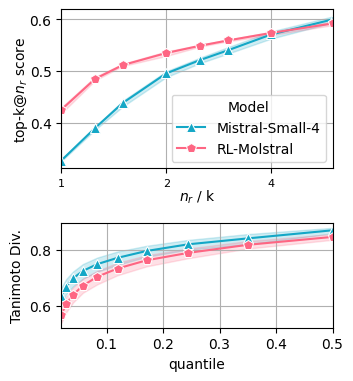

In [21]:
fig_size = 3.5
aspect = 1.3


fig = plt.figure(figsize=(fig_size,fig_size*aspect))

gs_top = fig.add_gridspec(1, 1, top=0.7, bottom=0.35)
ax_main = fig.add_subplot(gs_top[0, 0])
sns.lineplot(topk_df.groupby(["Model", "k", "$n_r$ / k"])["top-k"].mean().reset_index(), x="$n_r$ / k", y="top-k", hue="Model", style="Model", palette=CMAP_MODELS, markers=MARKER_MODELS, dashes=False, markersize=7, ax=ax_main)
ax_main.set_xscale('log', base=2)
ax_main.set_xticks([1, 2, 4])
ax_main.set_xticklabels(['1', '2', '4'], size=8)
ax_main.set_xlabel("$n_r$ / k", loc="center", labelpad=-0.1)
ax_main.set_ylabel("top-k@$n_r$ score", labelpad=-0.1)
ax_main.set_xlim(1,6)
ax_main.grid()


gs_bottom = fig.add_gridspec(1, 1, top=0.23, bottom=0.)
ax_sim_plot = fig.add_subplot(gs_bottom[0, 0])
sns.lineplot(div_df_grpo, x="quantile", y="Tanimoto Div.", hue="Model", palette=CMAP_MODELS, ax=ax_sim_plot, legend=False, style="Model", dashes=False, markers=MARKER_MODELS, markersize=7)
ax_sim_plot.set_xlim(QUANTILES[0], QUANTILES[-1])
# ax_sim_plot.set_xscale('log', base=10)
ax_sim_plot.grid()


plt.savefig(f"{FIG_PATH}/topk_mosaic.pdf", bbox_inches='tight')
plt.show()


# Tables for Top-k

In [22]:
from notebooks.metadata.molgen import MODEL_META
from notebooks.utils import aggregate_molgen_fn
LATEX_PATH = "MolGenDocking-latex/tables/results"

In [37]:
# Create table with: model_name, size, metric_name, value
import re

Ks = [1,4,16]
N_r = [16,24,32]

N_reperform = 2

table = []
size_pattern = re.compile(r'(?i)(?:^|[-_])(\d+\s*[b])(?:$|[-_])')
pbar = tqdm(total=len(df.model.unique())*len(N_r) * len(Ks) * N_reperform)
df.model = df.model.apply(lambda x: "Mistral-Small-4-128B" if  x == "Mistral-Small-128B" else x)

for model_name in df.model.unique():
    assert any([m in model_name for m in MODEL_META.keys()]), f"Model {model_name} not found in MODEL_META"
    key = [m for m in MODEL_META.keys() if m in model_name][0]
    metadata = MODEL_META[key]
    for k in Ks:
        for n_rollout in N_r:
            for _ in range(N_reperform):
                sub_df = df[df.model == model_name]
                # sub_df = sub_df.drop_duplicates(subset=["prompt_id", "smiles"])
                pass_k = sub_df.groupby("prompt_id").apply(
                    aggregate_molgen_fn("topk",k=k, n_rollout=n_rollout)
                ).to_frame().rename(columns={0:str(k)}).reset_index()
                if not "size" in metadata:
                    try:
                        size = size_pattern.search(model_name).group(1).upper()
                    except:
                        raise ValueError(f"Size not found for model {model_name}")
                else:
                    size = metadata["size"]
                for i, row in pass_k.iterrows():
                    thinking = r"\CheckmarkBold" if metadata["thinking"] else r"\XSolidBrush"
                    chem = r"\CheckmarkBold" if metadata["Chem."] else r"\XSolidBrush"

                    table.append(
                        [
                            model_name,
                            size,
                            thinking,
                            chem,
                            f"$n_r=${n_rollout}",
                            k,
                            row[str(k)],
                            row["prompt_id"]
                        ]
                    )
                pbar.update(1)
table= pd.DataFrame(columns=["model", "Size", "Think.", "Chem.", "Metric", "k", "Value", "prompt_id"], data=table)



 21%|██▏       | 145/675 [00:20<01:14,  7.13it/s]


  0%|          | 1/270 [00:00<00:35,  7.52it/s]

  1%|          | 2/270 [00:00<00:32,  8.36it/s]

  1%|          | 3/270 [00:00<00:30,  8.70it/s]

  1%|▏         | 4/270 [00:00<00:29,  8.91it/s]

  2%|▏         | 5/270 [00:00<00:32,  8.23it/s]

  2%|▏         | 6/270 [00:00<00:32,  8.18it/s]

  3%|▎         | 7/270 [00:00<00:31,  8.25it/s]

  3%|▎         | 8/270 [00:00<00:31,  8.41it/s]

  3%|▎         | 9/270 [00:01<00:30,  8.63it/s]

  4%|▎         | 10/270 [00:01<00:29,  8.70it/s]

  4%|▍         | 11/270 [00:01<00:30,  8.46it/s]

  4%|▍         | 12/270 [00:01<00:30,  8.57it/s]

  5%|▍         | 13/270 [00:01<00:29,  8.82it/s]

  5%|▌         | 14/270 [00:01<00:28,  8.91it/s]

  6%|▌         | 15/270 [00:01<00:30,  8.37it/s]

  6%|▌         | 16/270 [00:01<00:32,  7.71it/s]

  6%|▋         | 17/270 [00:02<00:32,  7.85it/s]

  7%|▋         | 18/270 [00:02<00:32,  7.83it/s]

  7%|▋         | 19/270 [00:02<00:32,  7.66it/s]

  7%|

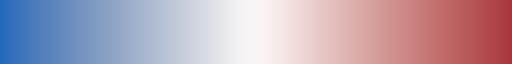

In [44]:
from notebooks.utils.utils import process_model_name

MODEL_ORDER = [
    "gemma-4",
    "Mistral-Small-4",
    "MiniMax-M2",
    "Qwen3",
    "Qwen3-Next",
    "gpt-oss",
    "R1-Llama",
    "R1-Qwen",
    "gemma-3",
    "Llama-3.3",
    "RL-Mistral",
    "RL-Molstral",
    "ChemDFM-R",
    "ether0",
    "ChemDFM-v2.0",
]

table["K"] = table["k"].apply(lambda x: "top_{" + str(x) + "}")
table["Model"] = table["model"].apply(process_model_name)
table[r"Size (B)"] = table["Size"].apply(lambda x: str(x).replace("B", ""))

cmap = sns.color_palette("vlag", as_cmap=True)
cmap

In [47]:
table

,model,Size,Think.,Chem.,Metric,k,Value,prompt_id,K,Model,Size (B)
0,ChemDFM-R-14B,14B,\XSolidBrush,\CheckmarkBold,$n_r=$16,1,0.799000,104510,top_{1},ChemDFM-R,14
1,ChemDFM-R-14B,14B,\XSolidBrush,\CheckmarkBold,$n_r=$16,1,0.806226,12041039143201,top_{1},ChemDFM-R,14
2,ChemDFM-R-14B,14B,\XSolidBrush,\CheckmarkBold,$n_r=$16,1,1.000000,12083-106,top_{1},ChemDFM-R,14
3,ChemDFM-R-14B,14B,\XSolidBrush,\CheckmarkBold,$n_r=$16,1,0.870057,134310391320,top_{1},ChemDFM-R,14
4,ChemDFM-R-14B,14B,\XSolidBrush,\CheckmarkBold,$n_r=$16,1,0.776129,1348103906320390700,top_{1},ChemDFM-R,14
...,...,...,...,...,...,...,...,...,...,...,...
13225,gpt-oss-120b,120B,\CheckmarkBold,\XSolidBrush,$n_r=$32,16,0.594379,3914324350110,top_{16},gpt-oss,120
13226,gpt-oss-120b,120B,\CheckmarkBold,\XSolidBrush,$n_r=$32,16,0.159049,39160049210,top_{16},gpt-oss,120
13227,gpt-oss-120b,120B,\CheckmarkBold,\XSolidBrush,$n_r=$32,16,0.272766,49210,top_{16},gpt-oss,120
13228,gpt-oss-120b,120B,\CheckmarkBold,\XSolidBrush,$n_r=$32,16,0.417984,54610,top_{16},gpt-oss,120


In [54]:
table.groupby(["Model", "Metric", "k", "prompt_id"]).Value.std().reset_index().groupby(["Model", "Metric", "k"]).Value.mean()

Model      Metric    k 
ChemDFM-R  $n_r=$16  1     0.042031
                     4     0.064159
                     16    0.034174
           $n_r=$24  1     0.043789
                     4     0.062233
                             ...   
gpt-oss    $n_r=$24  4     0.035147
                     16    0.042030
           $n_r=$32  1     0.020160
                     4     0.030248
                     16    0.034728
Name: Value, Length: 135, dtype: float64

In [50]:
from notebooks.utils import PandasTableFormatter

def color_map(val: float) -> str:
    "Returns a color based on the value (eg '#FF5733')"
    val = np.clip(val, -0.2, 0.65)
    color = cmap(val)
    return f"rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})"

formatter = PandasTableFormatter(
    n_decimals = 2, # Number of decimals to keep in the table
    aggregation_methods=["mean", "std"], # Aggregation functions to apply to the data
    main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
    hide_agg_labels=True, # Hide the aggregation column names in the latex
    global_agg=False, # Whether to compute global aggregation across all columns (True)
    color_mapping =color_map,
)

style = formatter.style(
    table, # Dataframe to format
    rows= ["Model", r"Size (B)", r"Think."], # Rows
    cols=["Metric", r"K"], # Columns
    values= "Value", # Values
    highlight_fn= np.nanmax, # Function to use to highlight the values, here the maximum values will be highlighted
    props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex",], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
    special_format_agg = {
        "std": lambda x: "\\tiny $\\pm$" + x, # Format to apply to the standard deviation values
    },
    remove_col_names=True,
    row_order = MODEL_ORDER
)
formatter.save_to_latex(
    style, f"{LATEX_PATH}/gen_table.tex", 0, multicol_align="c", hrules=True,
)
style

Model
Size (B)
Think.


In [ ]:
formatter = PandasTableFormatter(
    n_decimals = 2, # Number of decimals to keep in the table
    aggregation_methods=["mean", "std"], # Aggregation functions to apply to the data
    main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
    hide_agg_labels=True, # Hide the aggregation column names in the latex
    global_agg=False # Whether to compute global aggregation across all columns (True)
)

style = formatter.style(
    table, # Dataframe to format
    rows= ["Model",], # Rows
    cols=["Metric", r"K"], # Columns
    values= "Value", # Values
    highlight_fn= np.nanmax, # Function to use to highlight the values, here the maximum values will be highlighted
    props=["font-weight: bold; text-decoration: underline;", "text-decoration: underline;"], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
    special_format_agg = {
        "std": lambda x: "\\tiny " + x, # Format to apply to the standard deviation values
    },
    remove_col_names=True,
    row_order = MODEL_ORDER
)
col_sep = "c|"  + "|p{0.4cm}p{0.3cm}" * table.groupby(["Metric", r"K"]).ngroups
formatter.save_to_latex(style, f"{LATEX_PATH}/gen_table_std.tex", col_sep, multicol_align="|c|", hrules=True, n_first_cols=2)